In [29]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

OMP_NUM_THREADS = 1

In [30]:
path = "data/dames_with_energy.csv"   # load the data
df = pd.read_csv(path)

df.head()


,id,retest,sequence,correctness,validity,enc_task,enc_response,rt,task_vec,response_vec,energy_2,E_One,energy_sqrt,energy_sqrt_pc,E_One_sqrt,E_One_sqrt_pc,task_success,task_success_zs
0,dames-2022-time__1,0,0,0,1,AI2,NVC,9.755,[1 1 0 1 1 0],[0 0 0 0],2.166667,0.539683,1.471960,0.045239,0.734631,-1.036666,0.45,1.752934
1,dames-2022-time__1,0,1,1,0,OI3,NVC,7.642,[0 0 0 1 0 1],[0 0 0 0],1.500000,0.539683,1.224745,-0.440751,0.734631,-1.036666,0.09,0.305868
2,dames-2022-time__1,0,2,1,1,AE3,Eca,5.338,[1 1 1 0 0 1],[1 0 0 1],2.166667,0.841270,1.471960,0.045239,0.917208,0.557923,0.37,1.431364
3,dames-2022-time__1,0,3,0,0,IA3,Ica,10.387,[0 1 1 1 0 1],[0 1 0 1],2.333333,0.952381,1.527525,0.154472,0.975900,1.070531,-0.16,-0.699038
4,dames-2022-time__1,0,4,0,0,AI3,Oca,42.084,[1 1 0 1 0 1],[0 0 0 1],2.833333,0.920635,1.683251,0.460606,0.959497,0.927271,-0.14,-0.618646


### delimiter function

In [31]:
def parse_vec(s):
    if pd.isna(s):
        return None
    s = str(s).strip()
    s = s.strip("[]")
    if s == "":
        return []
    # split on commas OR whitespace
    parts = re.split(r"[,\s]+", s.strip())
    return [int(p) for p in parts if p != ""]


#### Sanity check

In [32]:
df["task_vec_list"] = df["task_vec"].apply(parse_vec)
df["response_vec_list"] = df["response_vec"].apply(parse_vec)

# quick sanity check
df[["task_vec", "task_vec_list", "response_vec", "response_vec_list"]].head(10)


,task_vec,task_vec_list,response_vec,response_vec_list
0,[1 1 0 1 1 0],"[1, 1, 0, 1, 1, 0]",[0 0 0 0],"[0, 0, 0, 0]"
1,[0 0 0 1 0 1],"[0, 0, 0, 1, 0, 1]",[0 0 0 0],"[0, 0, 0, 0]"
2,[1 1 1 0 0 1],"[1, 1, 1, 0, 0, 1]",[1 0 0 1],"[1, 0, 0, 1]"
3,[0 1 1 1 0 1],"[0, 1, 1, 1, 0, 1]",[0 1 0 1],"[0, 1, 0, 1]"
4,[1 1 0 1 0 1],"[1, 1, 0, 1, 0, 1]",[0 0 0 1],"[0, 0, 0, 1]"
5,[1 1 0 0 0 0],"[1, 1, 0, 0, 0, 0]",[0 0 0 0],"[0, 0, 0, 0]"
6,[1 0 1 1 1 1],"[1, 0, 1, 1, 1, 1]",[0 0 0 0],"[0, 0, 0, 0]"
7,[0 1 1 0 0 1],"[0, 1, 1, 0, 0, 1]",[1 0 0 1],"[1, 0, 0, 1]"
8,[0 1 0 1 1 1],"[0, 1, 0, 1, 1, 1]",[0 0 0 0],"[0, 0, 0, 0]"
9,[1 1 1 0 0 0],"[1, 1, 1, 0, 0, 0]",[1 0 0 1],"[1, 0, 0, 1]"


In [33]:
# Format convertion (From Dataframe to numeric)

task_mat = np.vstack(df["task_vec_list"].values)
resp_mat = np.vstack(df["response_vec_list"].values)

X = np.hstack([
    task_mat,
    resp_mat,
    df[["energy_2", "energy_sqrt", "correctness", "rt"]].to_numpy()
])

resp_mat

array([[0, 0, 0, 0],
       [0, 0, 0, 0],
       [1, 0, 0, 1],
       ...,
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0]], shape=(12800, 4))

All features were standardized to zero mean and unit variance prior to clustering. The number of clusters was selected by fitting k-means models for $k=2,\dots,10$ and choosing the value of (k) that maximized the silhouette score, which quantifies within-cluster cohesion relative to between-cluster separation.



In [34]:
# turn list vectors into columns first
task_cols = [f"task_{i}" for i in range(len(df["task_vec_list"].iloc[0]))]
resp_cols = [f"resp_{i}" for i in range(len(df["response_vec_list"].iloc[0]))]

task_df = pd.DataFrame(task_mat, columns=task_cols, index=df.index)
resp_df = pd.DataFrame(resp_mat, columns=resp_cols, index=df.index)

df_num = pd.concat([df[["id", "energy_2", "energy_sqrt","correctness"]], task_df, resp_df], axis=1)

# aggregate by person
g = df_num.groupby("id").mean(numeric_only=True).reset_index()
g.head()


,id,energy_2,energy_sqrt,correctness,task_0,task_1,task_2,task_3,task_4,task_5,resp_0,resp_1,resp_2,resp_3
0,dames-2022-time__1,2.203125,1.397461,0.546875,0.5,0.5,0.5,0.5,0.5,0.5,0.250000,0.203125,0.203125,0.312500
1,dames-2022-time__10,2.072917,1.324616,0.687500,0.5,0.5,0.5,0.5,0.5,0.5,0.101562,0.195312,0.296875,0.281250
2,dames-2022-time__100,2.223958,1.355442,0.226562,0.5,0.5,0.5,0.5,0.5,0.5,0.320312,0.460938,0.117188,0.789062
3,dames-2022-time__101,1.744792,1.187038,0.757812,0.5,0.5,0.5,0.5,0.5,0.5,0.093750,0.171875,0.273438,0.210938
4,dames-2022-time__102,2.671875,1.545952,0.289062,0.5,0.5,0.5,0.5,0.5,0.5,0.289062,0.421875,0.148438,0.726562


In [35]:
# aggregate by person
g = df_num.groupby("id").mean(numeric_only=True).reset_index()
g.head()

,id,energy_2,energy_sqrt,correctness,task_0,task_1,task_2,task_3,task_4,task_5,resp_0,resp_1,resp_2,resp_3
0,dames-2022-time__1,2.203125,1.397461,0.546875,0.5,0.5,0.5,0.5,0.5,0.5,0.250000,0.203125,0.203125,0.312500
1,dames-2022-time__10,2.072917,1.324616,0.687500,0.5,0.5,0.5,0.5,0.5,0.5,0.101562,0.195312,0.296875,0.281250
2,dames-2022-time__100,2.223958,1.355442,0.226562,0.5,0.5,0.5,0.5,0.5,0.5,0.320312,0.460938,0.117188,0.789062
3,dames-2022-time__101,1.744792,1.187038,0.757812,0.5,0.5,0.5,0.5,0.5,0.5,0.093750,0.171875,0.273438,0.210938
4,dames-2022-time__102,2.671875,1.545952,0.289062,0.5,0.5,0.5,0.5,0.5,0.5,0.289062,0.421875,0.148438,0.726562


1100


C:\Users\bcle\miniforge3\envs\meta-analysis\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\bcle\miniforge3\envs\meta-analysis\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\bcle\miniforge3\envs\meta-analysis\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\bcle\miniforge3\envs\meta-analysis\Lib\site-packages\sklearn\cluster\_

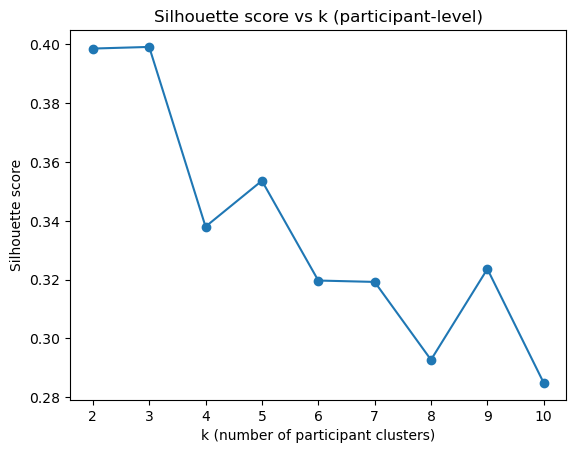

In [36]:
X = g.drop(columns=["id", "correctness", "energy_2"]).to_numpy()
Xz = StandardScaler().fit_transform(X)
print((Xz.size))

sil = {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=50, random_state=0)
    labels = km.fit_predict(Xz)
    sil[k] = silhouette_score(Xz, labels)

best_k = max(sil, key=sil.get)
best_k, sil[best_k]


ks = sorted(sil.keys())
scores = [sil[k] for k in ks]

plt.figure()
plt.plot(ks, scores, marker="o")
plt.xticks(ks)
plt.xlabel("k (number of participant clusters)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score vs k (participant-level)")
plt.show()




Number of participants: 100


C:\Users\bcle\miniforge3\envs\meta-analysis\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\bcle\miniforge3\envs\meta-analysis\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\bcle\miniforge3\envs\meta-analysis\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\bcle\miniforge3\envs\meta-analysis\Lib\site-packages\sklearn\cluster\_

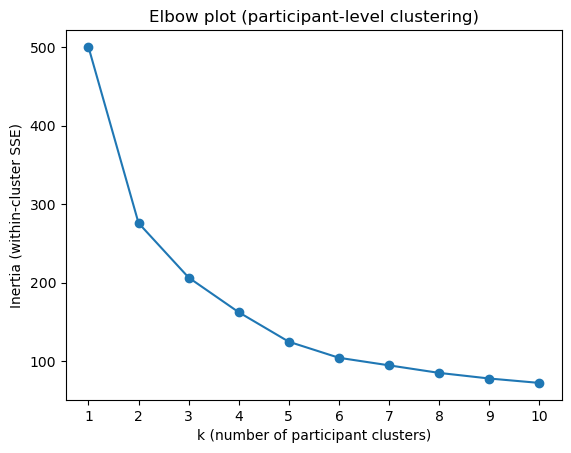

In [37]:
# g = participant-level table (1 row per id)
print("Number of participants:", len(g))

# keep only numeric feature columns
feature_cols = [c for c in g.columns if c not in ["id", "cluster_person", "correctness", "energy_2"]]
X = g[feature_cols].to_numpy()

# standardize
Xz = StandardScaler().fit_transform(X)

inertia = []
ks_elbow = list(range(1, 11))

for k in ks_elbow:
    km = KMeans(n_clusters=k, n_init=50, random_state=0)
    km.fit(Xz)
    inertia.append(km.inertia_)
plt.figure()
plt.plot(ks_elbow, inertia, marker="o")
plt.xticks(ks_elbow)
plt.xlabel("k (number of participant clusters)")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow plot (participant-level clustering)")
plt.show()


In [38]:
km = KMeans(n_clusters=best_k, n_init=100, random_state=0)
g["cluster_person"] = km.fit_predict(Xz)

g[["id", "cluster_person", "energy_2", "energy_sqrt", "correctness"]].sort_values(["cluster_person","energy_2"]).head(20)


C:\Users\bcle\miniforge3\envs\meta-analysis\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,id,cluster_person,energy_2,energy_sqrt,correctness
95,dames-2022-time__95,0,1.135417,0.858504,0.625000
65,dames-2022-time__65,0,1.218750,0.905866,0.796875
26,dames-2022-time__29,0,1.281250,0.956797,0.757812
25,dames-2022-time__28,0,1.453125,1.044407,0.851562
88,dames-2022-time__89,0,1.484375,1.010192,0.765625
18,dames-2022-time__21,0,1.531250,1.108787,0.664062
99,dames-2022-time__99,0,1.531250,1.109323,0.726562
12,dames-2022-time__14,0,1.536458,1.116137,0.671875
37,dames-2022-time__4,0,1.557292,1.089923,0.804688
31,dames-2022-time__33,0,1.562500,1.041545,0.585938


In [39]:
g.groupby("cluster_person")[["energy_2", "energy_sqrt", "correctness"]].agg(["mean","std","count"]).round(4)


energy_2               energy_sqrt               correctness  \
                   mean     std count        mean     std count        mean   
cluster_person                                                                
0                1.8424  0.3122    49      1.2255  0.1474    49      0.6722   
1                2.8415  0.4319    39      1.6127  0.1304    39      0.3798   
2                2.3355  0.5409    12      1.4232  0.1750    12      0.3034   

                              
                   std count  
cluster_person                
0               0.1078    49  
1               0.1008    39  
2               0.1064    12

In [40]:
g.groupby("cluster_person")[resp_cols].mean().round(3)


,resp_0,resp_1,resp_2,resp_3
cluster_person,,,,
0,0.127,0.183,0.274,0.237
1,0.257,0.362,0.425,0.369
2,0.270,0.446,0.712,0.126


g rows: 100


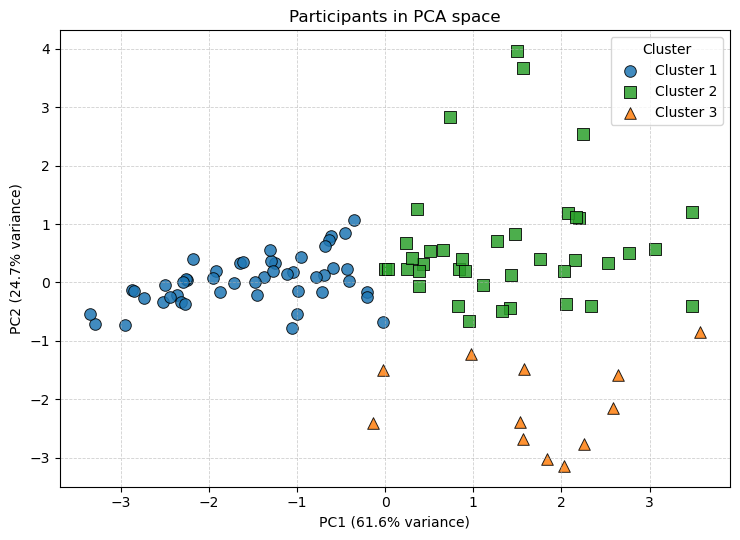

Saved: participant_pca_clusters.pdf


In [41]:
# --- Participant-level PCA scatter (color + shape, print-safe) ---
print("g rows:", len(g))

label_col = "cluster_person"  # adjust if needed

# numeric feature matrix
exclude = {"id", "correctness","rt","energy_2", label_col}
feature_cols = [c for c in g.columns if c not in exclude]
X = g[feature_cols].to_numpy()

# standardize
Xz = StandardScaler().fit_transform(X)

# labels
labels = g[label_col].to_numpy().astype(int)
assert Xz.shape[0] == len(labels), (Xz.shape[0], len(labels))

# PCA
pca = PCA(n_components=2, random_state=0)
Z = pca.fit_transform(Xz)
evr = pca.explained_variance_ratio_

# marker + color palettes
markers = ["o", "s", "^", "D", "v", "P"]
colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728", "#9467bd"]

unique_labels = np.unique(labels)

plt.figure(figsize=(7.5, 5.5))

for idx, lab in enumerate(unique_labels):
    m = markers[idx % len(markers)]
    c = colors[idx % len(colors)]
    mask = labels == lab

    plt.scatter(
        Z[mask, 0],
        Z[mask, 1],
        s=70,
        marker=m,
        facecolors=c,
        edgecolors="black",
        linewidths=0.7,
        alpha=0.85,
        label=f"Cluster {lab + 1}"
    )

plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
plt.xlabel(f"PC1 ({evr[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({evr[1]*100:.1f}% variance)")
plt.title("Participants in PCA space")

plt.legend(title="Cluster", loc="best", frameon=True)
plt.tight_layout()

# ---- SAVE AS PDF ----
out_pdf = "participant_pca_clusters.pdf"
plt.savefig(out_pdf, format="pdf", bbox_inches="tight")
plt.show()

print("Saved:", out_pdf)

C:\Users\bcle\miniforge3\envs\meta-analysis\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\bcle\miniforge3\envs\meta-analysis\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\bcle\miniforge3\envs\meta-analysis\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\bcle\miniforge3\envs\meta-analysis\Lib\site-packages\sklearn\cluster\_

best_k: 3 silhouette: 0.3991638575820459


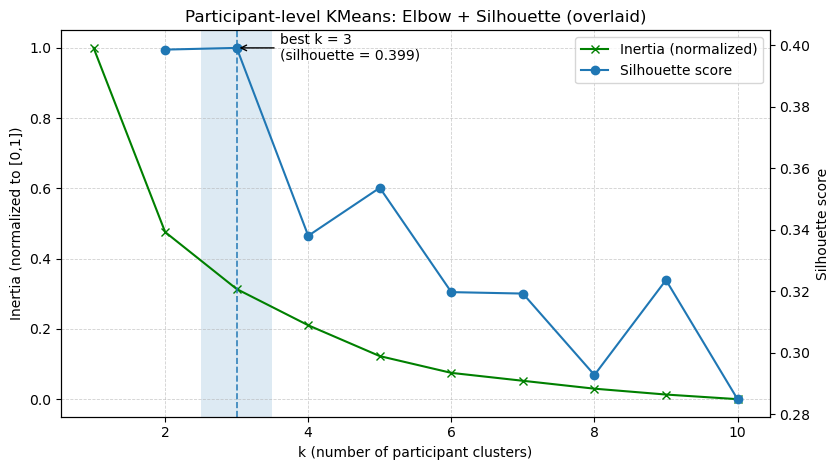

Saved: participant_kmeans_overlay_elbow_silhouette.pdf


In [42]:

# --- Build participant-level matrix ---
exclude = {"id", "cluster_person", "cluster", "correctness", "rt", "energy_2"}  # safe exclusions
feature_cols = [c for c in g.columns if c not in exclude]
X = g[feature_cols].to_numpy()
Xz = StandardScaler().fit_transform(X)

# --- Compute inertia and silhouette across k ---
ks_elbow = np.arange(1, 11)
inertia = []
for k in ks_elbow:
    km = KMeans(n_clusters=k, n_init=50, random_state=0)
    km.fit(Xz)
    inertia.append(km.inertia_)
inertia = np.array(inertia)

ks_sil = np.arange(2, 11)
sil = {}
for k in ks_sil:
    km = KMeans(n_clusters=k, n_init=50, random_state=0)
    labels = km.fit_predict(Xz)
    sil[k] = silhouette_score(Xz, labels)

best_k = max(sil, key=sil.get)
best_sil = sil[best_k]
print("best_k:", best_k, "silhouette:", best_sil)

# --- Normalize inertia to [0,1] so it can overlay with silhouette nicely ---
# (inertia decreases with k; normalized version shown as "relative inertia")
in_norm = (inertia - inertia.min()) / (inertia.max() - inertia.min() + 1e-12)

# Prepare series for overlay (silhouette only defined from k=2..10)
sil_vals = np.array([sil[k] for k in ks_sil])

# --- Make one overlapping figure with shaded region + best k annotation ---
fig, ax = plt.subplots(figsize=(8.5, 4.8))

# Grid
ax.grid(True, which="both", linestyle="--", linewidth=0.6, alpha=0.6)

# Plot normalized inertia on left axis
ax.plot(ks_elbow, in_norm, marker="x", color='green', label="Inertia (normalized)")
ax.set_xlabel("k (number of participant clusters)")
ax.set_ylabel("Inertia (normalized to [0,1])")

# Plot silhouette on right axis (twin axis)
ax2 = ax.twinx()
ax2.plot(ks_sil, sil_vals, marker="o", label="Silhouette score")
ax2.set_ylabel("Silhouette score")

# Mark "best k" with vertical line and shaded region around it
ax.axvline(best_k, linestyle="--", linewidth=1.2, alpha=0.9)
ax.axvspan(best_k - 0.5, best_k + 0.5, alpha=0.15)  # shaded region

# Add annotation text near the silhouette point
ax2.scatter([best_k], [best_sil])
ax2.annotate(
    f"best k = {best_k}\n(silhouette = {best_sil:.3f})",
    xy=(best_k, best_sil),
    xytext=(best_k + 0.6, best_sil),
    arrowprops=dict(arrowstyle="->", lw=1.0),
    va="center"
)

# Title
ax.set_title("Participant-level KMeans: Elbow + Silhouette (overlaid)")

# Combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="best")

fig.tight_layout()

# Save as PDF
out_pdf = "participant_kmeans_overlay_elbow_silhouette.pdf"
fig.savefig(out_pdf, format="pdf", bbox_inches="tight")
plt.show()

print("Saved:", out_pdf)


g rows: 100


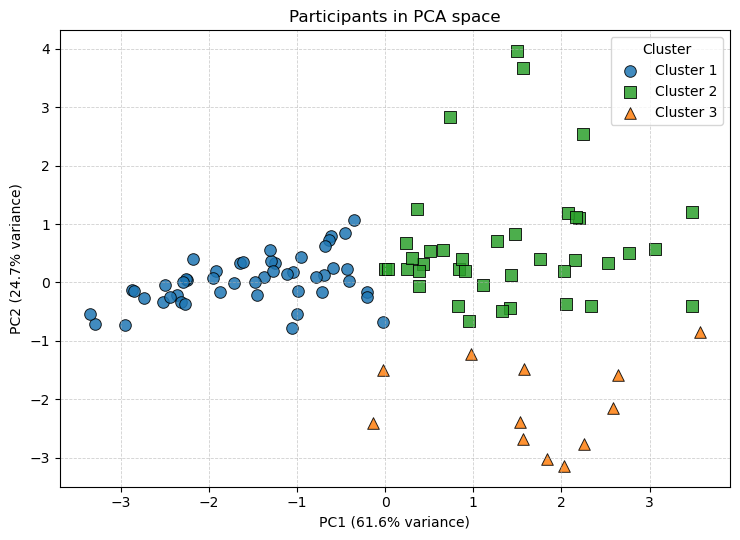

Saved: participant_pca_clusters.pdf


In [43]:
# --- Participant-level PCA scatter (color + shape, print-safe) ---
print("g rows:", len(g))

label_col = "cluster_person"  # adjust if needed

# numeric feature matrix
exclude = {"id", "correctness","rt","energy_2", label_col}
feature_cols = [c for c in g.columns if c not in exclude]
X = g[feature_cols].to_numpy()

# standardize
Xz = StandardScaler().fit_transform(X)

# labels
labels = g[label_col].to_numpy().astype(int)
assert Xz.shape[0] == len(labels), (Xz.shape[0], len(labels))

# PCA
pca = PCA(n_components=2, random_state=0)
Z = pca.fit_transform(Xz)
evr = pca.explained_variance_ratio_

# marker + color palettes
markers = ["o", "s", "^", "D", "v", "P"]
colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728", "#9467bd"]

unique_labels = np.unique(labels)

plt.figure(figsize=(7.5, 5.5))

for idx, lab in enumerate(unique_labels):
    m = markers[idx % len(markers)]
    c = colors[idx % len(colors)]
    mask = labels == lab

    plt.scatter(
        Z[mask, 0],
        Z[mask, 1],
        s=70,
        marker=m,
        facecolors=c,
        edgecolors="black",
        linewidths=0.7,
        alpha=0.85,
        label=f"Cluster {lab + 1}"
    )

plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
plt.xlabel(f"PC1 ({evr[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({evr[1]*100:.1f}% variance)")
plt.title("Participants in PCA space")

plt.legend(title="Cluster", loc="best", frameon=True)
plt.tight_layout()

# ---- SAVE AS PDF ----
out_pdf = "participant_pca_clusters.pdf"
plt.savefig(out_pdf, format="pdf", bbox_inches="tight")
plt.show()

print("Saved:", out_pdf)


In [44]:
pca = PCA(n_components=2, random_state=0)
Z = pca.fit_transform(Xz)
pca.explained_variance_ratio_


array([0.61648493, 0.24739846])

In [45]:
pca.components_

array([[ 5.09975733e-01,  0.00000000e+00,  0.00000000e+00,
        -8.67361738e-19,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  4.91054730e-01,  5.11486140e-01,
         4.35560889e-01,  2.17850051e-01],
       [ 2.21920151e-01,  1.38777878e-17,  2.22044605e-16,
        -0.00000000e+00, -0.00000000e+00,  0.00000000e+00,
         0.00000000e+00, -3.87408090e-02, -7.34210469e-02,
        -5.35407248e-01,  8.10678127e-01]])